In [1]:
import os
print(os.listdir("./stock_market_dataset/Stocks")[:10])
print(os.listdir("./stock_market_dataset/ETFs")[:10])

['rlj.us.txt', 'arnc_.us.txt', 'vjet.us.txt', 'snv.us.txt', 'fogo.us.txt', 'xom.us.txt', 'tve.us.txt', 'wmlp.us.txt', 'info.us.txt', 'pkw.us.txt']
['xpp.us.txt', 'slqd.us.txt', 'ezj.us.txt', 'csm.us.txt', 'uge.us.txt', 'iyc.us.txt', 'don.us.txt', 'jjp.us.txt', 'ydiv.us.txt', 'pxmg.us.txt']


In [2]:
import pandas as pd
pddf = pd.read_csv("./stock_market_dataset/ETFs/xpp.us.txt")

In [3]:
pddf.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2009-06-04,59.33,60.39,59.33,60.00,5725,0
1,2009-06-05,63.32,63.32,59.73,61.22,110241,0
2,2009-06-08,60.22,60.22,57.50,59.38,17906,0
3,2009-06-09,58.38,58.84,57.22,58.46,24541,0
4,2009-06-10,62.99,63.11,59.99,61.44,103407,0


In [4]:
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import os
from pathlib import Path


stocks_path = "./stock_market_dataset/Stocks"
etfs_path = "./stock_market_dataset/ETFs"

stock_files = [stocks_path+"/"+path for path in os.listdir(stocks_path)]
etfs_files = [etfs_path+"/"+path for path in os.listdir(etfs_path)]

def read_stocks(file_path):
    try:
        csv =  pd.read_csv(file_path)
        csv["company"] = Path(file_path).name
        csv["type"] = "stock"
        return csv
    except Exception as e:
        print(e)
        return None

stock_files_dfs = []
etfs_files_dfs = []

with ThreadPoolExecutor(max_workers=100) as executor:
    stock_files_dfs = list(executor.map(read_stocks,stock_files))

stock_files_dfs = [file for file in stock_files_dfs if file is not None]

len(stock_files_dfs)

def read_etfs(file_path):
    try:
        csv =  pd.read_csv(file_path)
        csv["company"] = Path(file_path).name
        csv["type"] = "etf"
        return csv
    except Exception as e:
        print(e)
        return None

with ThreadPoolExecutor(max_workers=100) as executor:
    etfs_files_dfs = list(executor.map(read_etfs,etfs_files))

etfs_files_dfs = [file for file in etfs_files_dfs if file is not None]

len(etfs_files_dfs)

No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file


1344

In [5]:
stock_files_dfs[100].head()

,Date,Open,High,Low,Close,Volume,OpenInt,company,type
0,2005-02-25,5.73,5.85,5.50,5.54,66432,0,refr.us.txt,stock
1,2005-02-28,5.52,5.66,5.00,5.14,95419,0,refr.us.txt,stock
2,2005-03-01,5.15,5.22,5.04,5.05,27293,0,refr.us.txt,stock
3,2005-03-02,5.08,5.16,5.03,5.05,39626,0,refr.us.txt,stock
4,2005-03-03,5.06,5.20,5.05,5.16,15776,0,refr.us.txt,stock


In [6]:
stocks_df = pd.concat(stock_files_dfs,ignore_index=True) 

In [7]:
stocks_df.iloc[14880000]

Date        2016-03-02
Open            10.921
High            10.996
Low             10.695
Close           10.941
Volume           94840
OpenInt              0
company    ctre.us.txt
type             stock
Name: 14880000, dtype: object

In [8]:
close_stocks_df = stocks_df[["Date","Close","company"]].copy()

In [9]:
close_stocks_min = close_stocks_df["Close"].min()
close_stocks_max = close_stocks_df["Close"].max()
print(close_stocks_min, close_stocks_max)

0.0037 1437986240.44


In [10]:
close_stocks_df["Close_scaled"] = (close_stocks_df["Close"]-close_stocks_min)/(close_stocks_max-close_stocks_min)

In [11]:
close_stocks_df.tail()

,Date,Close,company,Close_scaled
14887660,2017-10-31,26.60,cubi_d.us.txt,1.849552e-08
14887661,2017-11-01,26.75,cubi_d.us.txt,1.859983e-08
14887662,2017-11-02,26.78,cubi_d.us.txt,1.862069e-08
14887663,2017-11-07,26.75,cubi_d.us.txt,1.859983e-08
14887664,2017-11-10,26.75,cubi_d.us.txt,1.859983e-08


In [12]:
close_stocks_df["DateType_Date"] = pd.to_datetime(close_stocks_df["Date"])

In [13]:
stocks_start_date = close_stocks_df["DateType_Date"].min()
stocks_end_date = close_stocks_df["DateType_Date"].max()

In [14]:
stocks_x_axis = (stocks_end_date-stocks_start_date).days
print(stocks_x_axis)

20401


ValueError: x and y must have same first dimension, but have shapes (1,) and (2,)

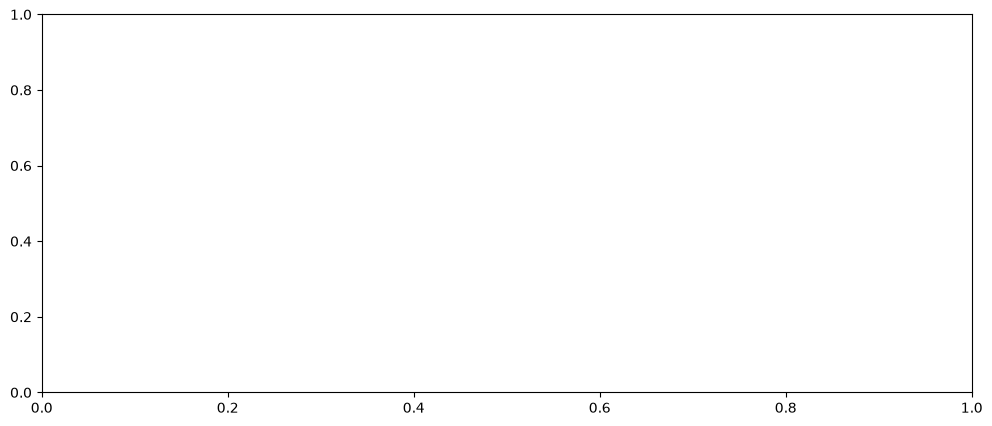

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

window_size = 500

fig, ax = plt.subplots(figsize=(12,6))
fig.subplots_adjust(bottom=0.25)



# Plot the initial 500 days
(line,) = ax.plot(stocks_x_axis, stocks_x_axis, color='#1f77b4', lw=1.5, label='Stock Price')

# Set strict Y-limits since your data is already normalized between 0 and 1
ax.set_ylim(-0.05, 1.05)
# Set the initial X-axis view (0 to 500)
ax.set_xlim(0, window_size)

# Add titles and grid labels
ax.set_title(
    'Single Company Stock Price - 20,000 Day Timeline',
    fontsize=14,
    pad=15,
    weight='bold',
)
ax.set_xlabel('Timeline (Days)', fontsize=11)
ax.set_ylabel('Normalized Price (0.0 - 1.0)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# 4. Create the slider axis [left, bottom, width, height] and the Slider widget
ax_slider = plt.axes([0.2, 0.08, 0.65, 0.04])
slider = Slider(
    ax_slider,
    label='Scroll Timeline ',
    valmin=0,
    valmax=stocks_x_axis - window_size,
    valinit=0,
    valstep=50,  # Moves by 50 days per click on the slider bar
    valfmt='%0.0f',
    color='#2ca02c',
)


# 5. Define what happens when the slider moves
def update_window(val):
  # Get the current slider position
  start_day = int(slider.val)

  # Shift the X-axis view window dynamically
  ax.set_xlim(start_day, start_day + window_size)

  # Redraw the canvas cleanly
  fig.canvas.draw_idle()


# Connect the slider to the update function
slider.on_changed(update_window)

plt.show()

In [70]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [15]:
# ==========================================
# STEP 1: PIVOT STOCK DATASET (Date x Company)
# ==========================================

import pandas as pd
import numpy as np

print("Pivoting stocks dataframe...")

# Pivot so rows are unique dates and columns are stock company tickers
pivoted_stocks = close_stocks_df.pivot(
    index="DateType_Date", columns="company", values="Close"
).sort_index()

# Display matrix dimensions and full date range
print(f"Pivoted Shape: {pivoted_stocks.shape} (Total Dates x Total Companies)")
print(
    f"Timeline Range: {pivoted_stocks.index.min().strftime('%Y-%m-%d')} to"
    f" {pivoted_stocks.index.max().strftime('%Y-%m-%d')}"
)

# Rank companies by historical date completeness (number of active trading days)
completeness = pivoted_stocks.notna().sum().sort_values(ascending=False)
top_companies = completeness.head(25).index.tolist()

print("\nTop 10 Companies with longest historical record:")
for c in top_companies[:10]:
  print(" -", c.replace(".us.txt", "").upper())

# Preview the pivoted DataFrame
pivoted_stocks.head()


Pivoting stocks dataframe...
Pivoted Shape: (14084, 7163) (Total Dates x Total Companies)
Timeline Range: 1962-01-02 to 2017-11-10

Top 10 Companies with longest historical record:
 - IBM
 - GE
 - HPQ
 - IP
 - DTE
 - MMM
 - MCD
 - CAT
 - NAV
 - PG


company,a.us.txt,aa.us.txt,aaap.us.txt,aaba.us.txt,aac.us.txt,aal.us.txt,aamc.us.txt,aame.us.txt,aan.us.txt,aaoi.us.txt,...,zoes.us.txt,zsan.us.txt,zto.us.txt,ztr.us.txt,zts.us.txt,zumz.us.txt,zvv.us.txt,zx.us.txt,zyme.us.txt,zyne.us.txt
DateType_Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# ==========================================
# STEP 2: BASE-100 PRICE NORMALIZATION
# ==========================================

# Formula: (Price at time t / Price on first trading day) * 100
# Every company starts at 100.0 on its first valid trading date
pivoted_norm = pivoted_stocks.apply(
    lambda col: (
        (col / col.dropna().iloc[0]) * 100 if not col.dropna().empty else col
    )
)

print("Base-100 Normalized Data Preview:")
pivoted_norm.head()


Base-100 Normalized Data Preview:


company,a.us.txt,aa.us.txt,aaap.us.txt,aaba.us.txt,aac.us.txt,aal.us.txt,aamc.us.txt,aame.us.txt,aan.us.txt,aaoi.us.txt,...,zoes.us.txt,zsan.us.txt,zto.us.txt,ztr.us.txt,zts.us.txt,zumz.us.txt,zvv.us.txt,zx.us.txt,zyme.us.txt,zyne.us.txt
DateType_Date,,,,,,,,,,,,,,,,,,,,,
1962-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


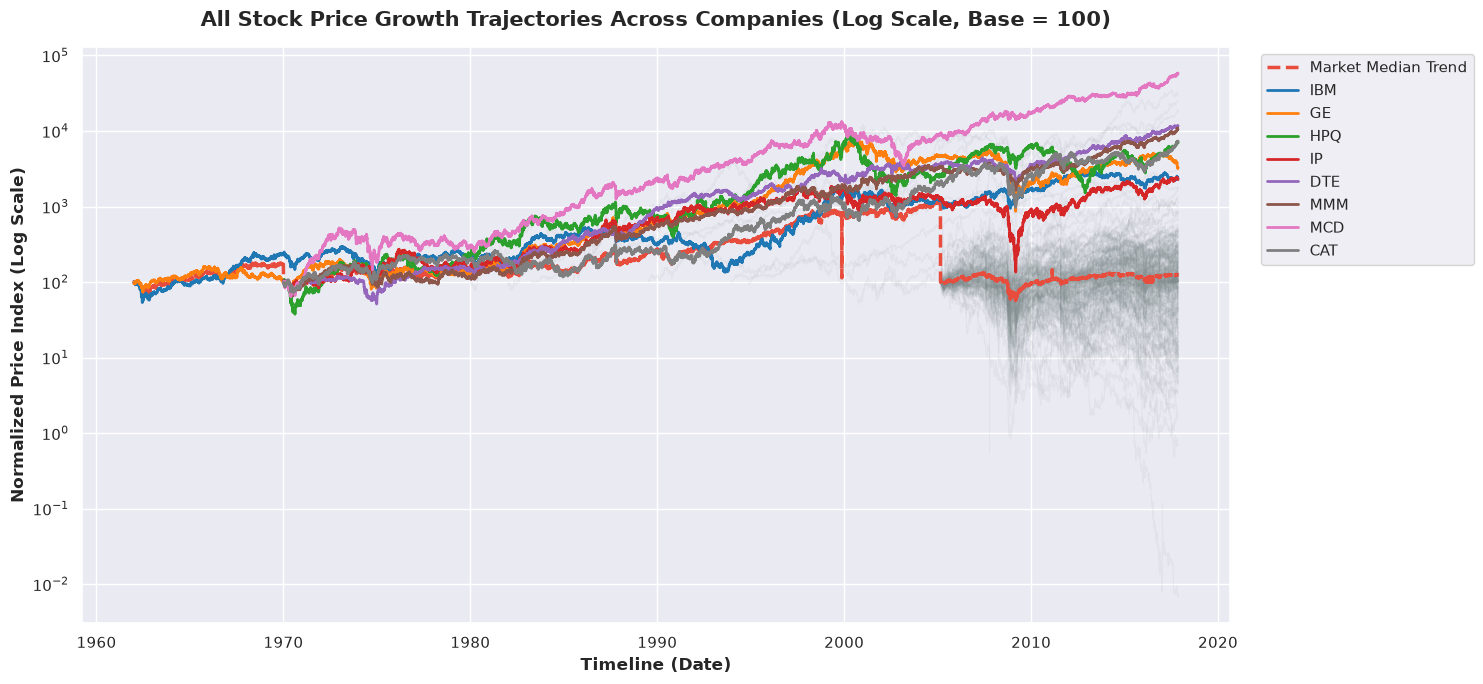

In [17]:
# ==========================================
# STEP 3: PLOT ALL STOCKS (FULL TIMELINE)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(15, 7))

# Sample 300 companies for background rendering to keep plot clean and fast
sample_cols = pivoted_norm.columns.to_series().sample(
    n=min(300, len(pivoted_norm.columns)), random_state=42
)

# Plot thin semi-transparent lines for sampled background stocks
for comp in sample_cols:
  ax.plot(
      pivoted_norm.index,
      pivoted_norm[comp],
      color="#7f8c8d",
      alpha=0.08,
      linewidth=0.8,
  )

# Calculate and plot the Overall Market Median Trend across all stocks
market_median = pivoted_norm.median(axis=1)
ax.plot(
    pivoted_norm.index,
    market_median,
    color="#e74c3c",
    linewidth=2.5,
    linestyle="--",
    label="Market Median Trend",
)

# Highlight top 8 companies with the longest trading history
palette = sns.color_palette("tab10", 8)
for idx, comp in enumerate(top_companies[:8]):
  ax.plot(
      pivoted_norm.index,
      pivoted_norm[comp],
      label=comp.replace(".us.txt", "").upper(),
      linewidth=2.0,
      color=palette[idx],
  )

# Logarithmic Y-axis scale to visualize multi-decade exponential growth
ax.set_yscale("log")

# Title and labels
ax.set_title(
    "All Stock Price Growth Trajectories Across Companies (Log Scale, Base ="
    " 100)",
    fontsize=15,
    pad=15,
    weight="bold",
)
ax.set_xlabel("Timeline (Date)", fontsize=12, weight="bold")
ax.set_ylabel(
    "Normalized Price Index (Log Scale)", fontsize=12, weight="bold"
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()


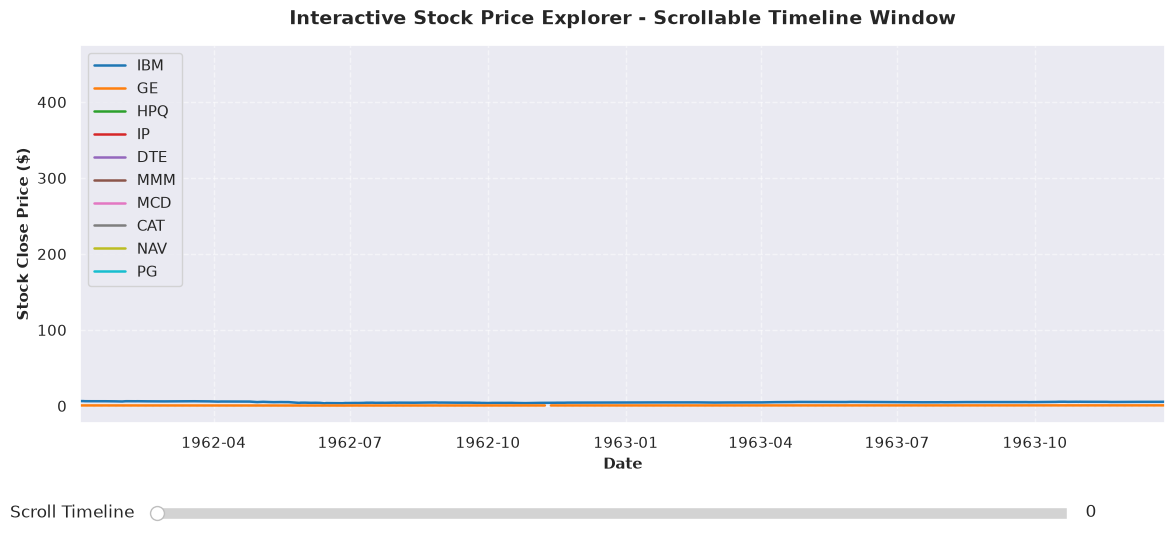

In [18]:
# ==========================================
# STEP 4: INTERACTIVE TIMELINE SLIDER
# ==========================================

from matplotlib.widgets import Slider

# Select top 10 companies for clear window inspection
top_10 = top_companies[:10]
dates_array = pivoted_stocks.index
window_size_days = 500  # Number of trading days in window view

fig, ax = plt.subplots(figsize=(14, 6))
plt.subplots_adjust(bottom=0.25)

# Plot stock price lines
colors = plt.cm.tab10(np.linspace(0, 1, len(top_10)))
for idx, comp in enumerate(top_10):
  ax.plot(
      dates_array,
      pivoted_stocks[comp],
      label=comp.replace(".us.txt", "").upper(),
      lw=1.8,
      color=colors[idx],
  )

# Set initial view window (Day 0 to window_size_days)
ax.set_xlim(
    dates_array[0], dates_array[min(window_size_days, len(dates_array) - 1)]
)
ax.set_title(
    "Interactive Stock Price Explorer - Scrollable Timeline Window",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Date", fontsize=11, weight="bold")
ax.set_ylabel("Stock Close Price ($)", fontsize=11, weight="bold")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper left")

# Create slider axis widget below main plot
ax_slider = plt.axes([0.18, 0.08, 0.65, 0.04])
slider = Slider(
    ax_slider,
    label="Scroll Timeline ",
    valmin=0,
    valmax=len(dates_array) - window_size_days,
    valinit=0,
    valstep=30,  # Shifts window by 30 days per step
    color="#2ca02c",
)


# Define update function for slider movement
def update_timeline(val):
  start_idx = int(slider.val)
  end_idx = min(start_idx + window_size_days, len(dates_array) - 1)

  # Update X-axis range
  ax.set_xlim(dates_array[start_idx], dates_array[end_idx])

  # Dynamically adjust Y-axis scaling to fit highest and lowest price in current window
  visible_data = pivoted_stocks[top_10].iloc[start_idx:end_idx]
  if not visible_data.dropna(how="all").empty:
    ymax = visible_data.max().max()
    ymin = visible_data.min().min()
    if not np.isnan(ymin) and not np.isnan(ymax):
      ax.set_ylim(max(0, ymin * 0.9), ymax * 1.1)

  fig.canvas.draw_idle()


# Connect slider widget to update function
slider.on_changed(update_timeline)
plt.show()


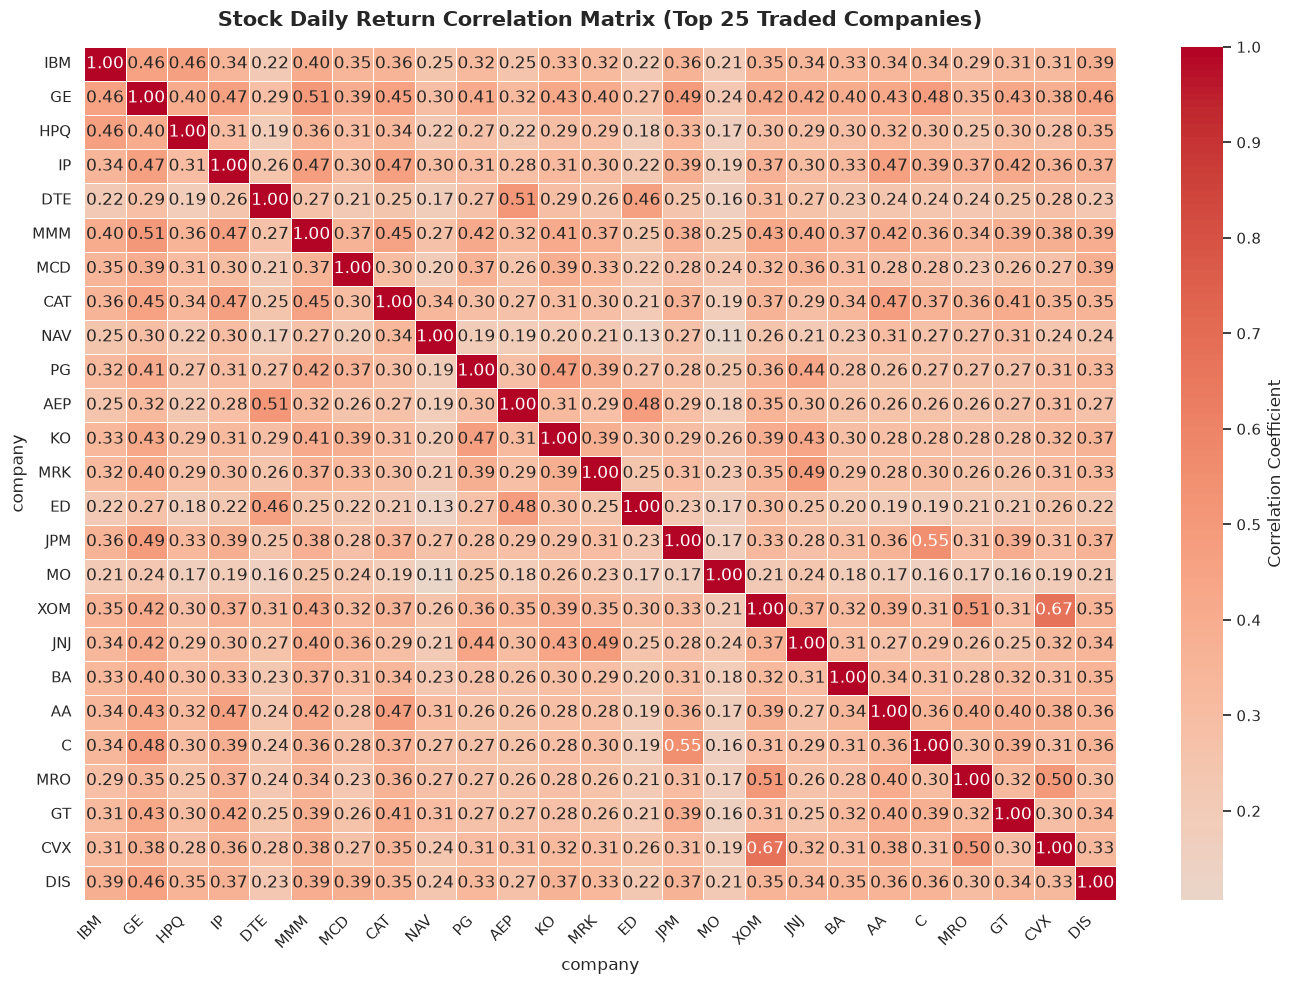

In [19]:
# ==========================================
# STEP 5: DAILY RETURNS CORRELATION HEATMAP
# ==========================================

# 1. Calculate daily percentage return for each stock
daily_returns = pivoted_stocks[top_companies[:25]].pct_change()

# 2. Compute Pearson correlation matrix
corr_matrix = daily_returns.corr()

# 3. Plot Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  # Red = Positive Correlation, Blue = Negative Correlation
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"},
)

plt.title(
    "Stock Daily Return Correlation Matrix (Top 25 Traded Companies)",
    fontsize=15,
    weight="bold",
    pad=15,
)
plt.xticks(
    ticks=np.arange(len(top_companies[:25])) + 0.5,
    labels=[c.replace(".us.txt", "").upper() for c in top_companies[:25]],
    rotation=45,
    ha="right",
)
plt.yticks(
    ticks=np.arange(len(top_companies[:25])) + 0.5,
    labels=[c.replace(".us.txt", "").upper() for c in top_companies[:25]],
    rotation=0,
)
plt.tight_layout()
plt.show()


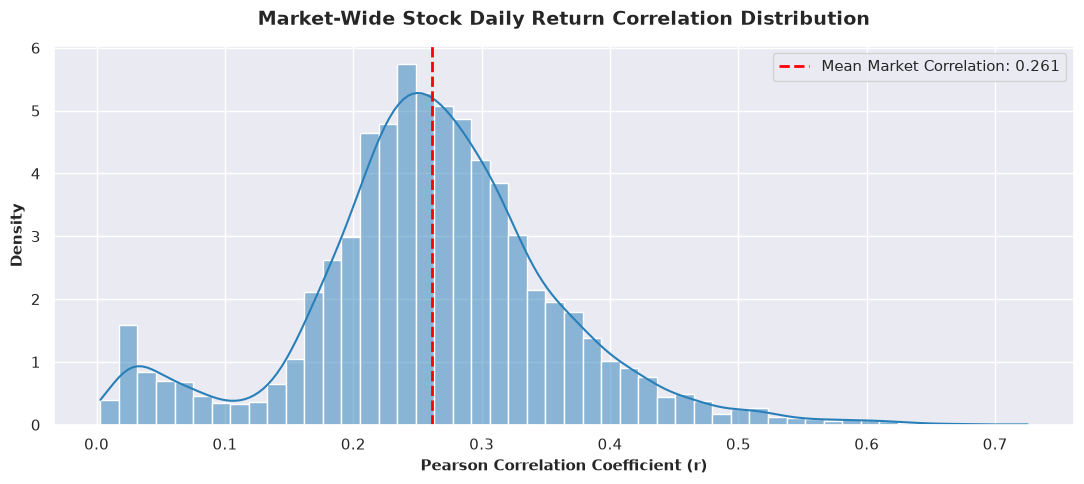

=== Top 10 Most Positively Correlated Stock Pairs ===


,Company_A,Company_B,Correlation
5564,SLB,HAL,0.725267
1623,XOM,CVX,0.674491
5284,CSX,NSC,0.663580
1087,AEP,DUK,0.642636
2381,CVX,COP,0.636036
1365,ED,SO,0.624627
4784,UNP,NSC,0.620290
1045,AEP,PEG,0.619600
5599,SLB,RDC,0.619354
1387,ED,DUK,0.619332



=== Top 10 Least / Most Negatively Correlated Stock Pairs ===


,Company_A,Company_B,Correlation
3946,DWDP,EIX,0.002964
4678,EIX,DE,0.003032
3978,DWDP,DE,0.008516
2939,INTC,DWDP,0.009041
4675,EIX,JCP,0.009497
4658,EIX,NOC,0.010127
3239,UIS,DWDP,0.010451
4647,EIX,UNP,0.012391
4992,DAL,NEM,0.012410
3957,DWDP,HUM,0.012544


In [21]:
# ==========================================
# STEP 6: CORRELATION DISTRIBUTION & TOP PAIRS (FIXED)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Calculate correlation matrix for top 100 companies
sample_100 = completeness.head(100).index
corr_100 = pivoted_stocks[sample_100].pct_change().corr()

# FIX: Rename index and columns to avoid duplicate 'company' level names when resetting index
corr_100.index.name = "Company_A"
corr_100.columns.name = "Company_B"

# 2. Extract upper triangle of correlation matrix (excluding self-correlations)
upper_mask = np.triu(np.ones(corr_100.shape), k=1).astype(bool)

# 3. Stack into a 2-column DataFrame of pairwise correlations
corr_pairs = corr_100.where(upper_mask).stack().reset_index()
corr_pairs.columns = ["Company_A", "Company_B", "Correlation"]

# Clean up ticker file extensions
corr_pairs["Company_A"] = (
    corr_pairs["Company_A"].str.replace(".us.txt", "").str.upper()
)
corr_pairs["Company_B"] = (
    corr_pairs["Company_B"].str.replace(".us.txt", "").str.upper()
)

# 4. Plot Market-Wide Correlation Distribution
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(
    corr_pairs["Correlation"],
    kde=True,
    color="#2980b9",
    bins=50,
    ax=ax,
    stat="density",
)

mean_corr = corr_pairs["Correlation"].mean()
ax.axvline(
    mean_corr,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Market Correlation: {mean_corr:.3f}",
)

ax.set_title(
    "Market-Wide Stock Daily Return Correlation Distribution",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Pearson Correlation Coefficient (r)", fontsize=11, weight="bold")
ax.set_ylabel("Density", fontsize=11, weight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# 5. Display Top 10 Positively Correlated Pairs
print("=== Top 10 Most Positively Correlated Stock Pairs ===")
display(corr_pairs.sort_values(by="Correlation", ascending=False).head(10))

# 6. Display Top 10 Negatively / Least Correlated Pairs
print("\n=== Top 10 Least / Most Negatively Correlated Stock Pairs ===")
display(corr_pairs.sort_values(by="Correlation", ascending=True).head(10))


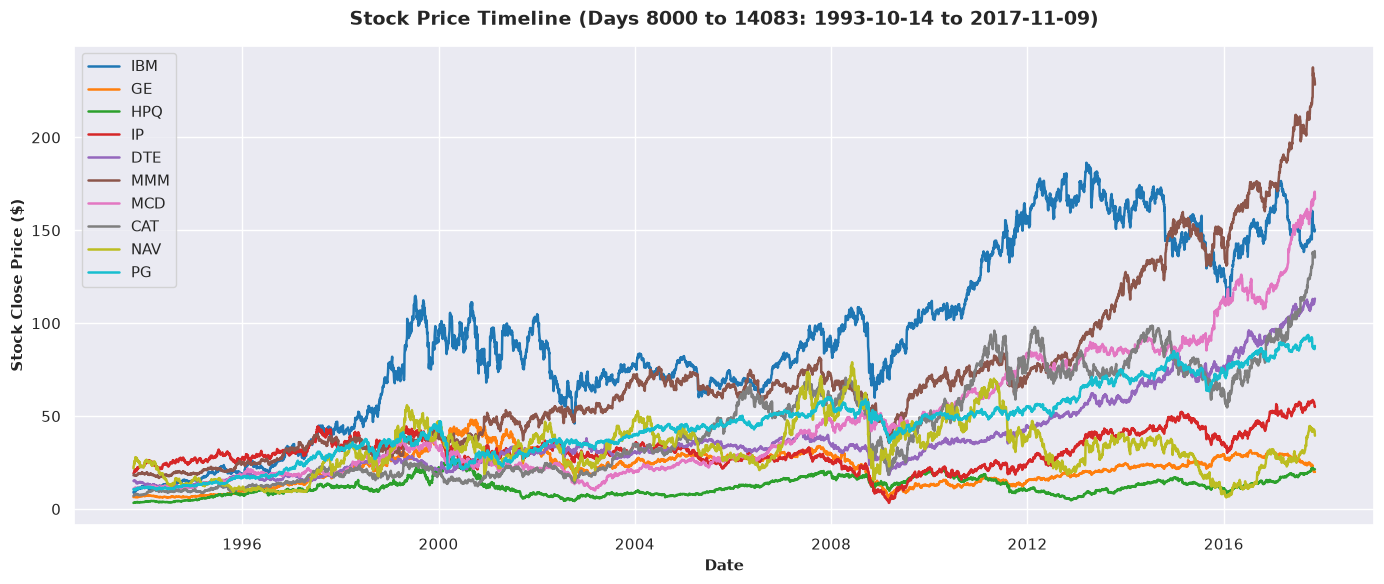

In [28]:
# ==========================================
# STEP 7: FAST TIMELINE GRAPH NAVIGATOR
# Uses pre-computed 'pivoted_stocks' & 'top_companies' from memory
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ---------------------------------------------------------
# CHANGE THESE 2 VARIABLES TO NAVIGATE THE TIMELINE INSTANTLY
# ---------------------------------------------------------
start_day = 8000  # Day offset from timeline start (e.g., 0, 500, 1500, 3000...)
window_size = 10000  # Number of trading days to display in the window

# Select top 10 companies from memory
top_10 = top_companies[:10]
dates_array = pivoted_stocks.index
total_days = len(dates_array)

# Calculate slice bounds safely
start_idx = min(max(0, start_day), total_days - 50)
end_idx = min(start_idx + window_size, total_days - 1)

# FAST SLICE: Slice existing DataFrame in memory
visible_dates = dates_array[start_idx:end_idx]
window_data = pivoted_stocks[top_10].iloc[start_idx:end_idx]

# ---------------------------------------------------------
# FAST PLOT RENDERING
# ---------------------------------------------------------
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(top_10)))
for idx, comp in enumerate(top_10):
  ax.plot(
      visible_dates,
      window_data[comp],
      label=comp.replace(".us.txt", "").upper(),
      lw=1.8,
      color=colors[idx],
  )

start_date_str = visible_dates[0].strftime("%Y-%m-%d")
end_date_str = visible_dates[-1].strftime("%Y-%m-%d")

ax.set_title(
    f"Stock Price Timeline (Days {start_idx} to {end_idx}: {start_date_str} to"
    f" {end_date_str})",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Date", fontsize=11, weight="bold")
ax.set_ylabel("Stock Close Price ($)", fontsize=11, weight="bold")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


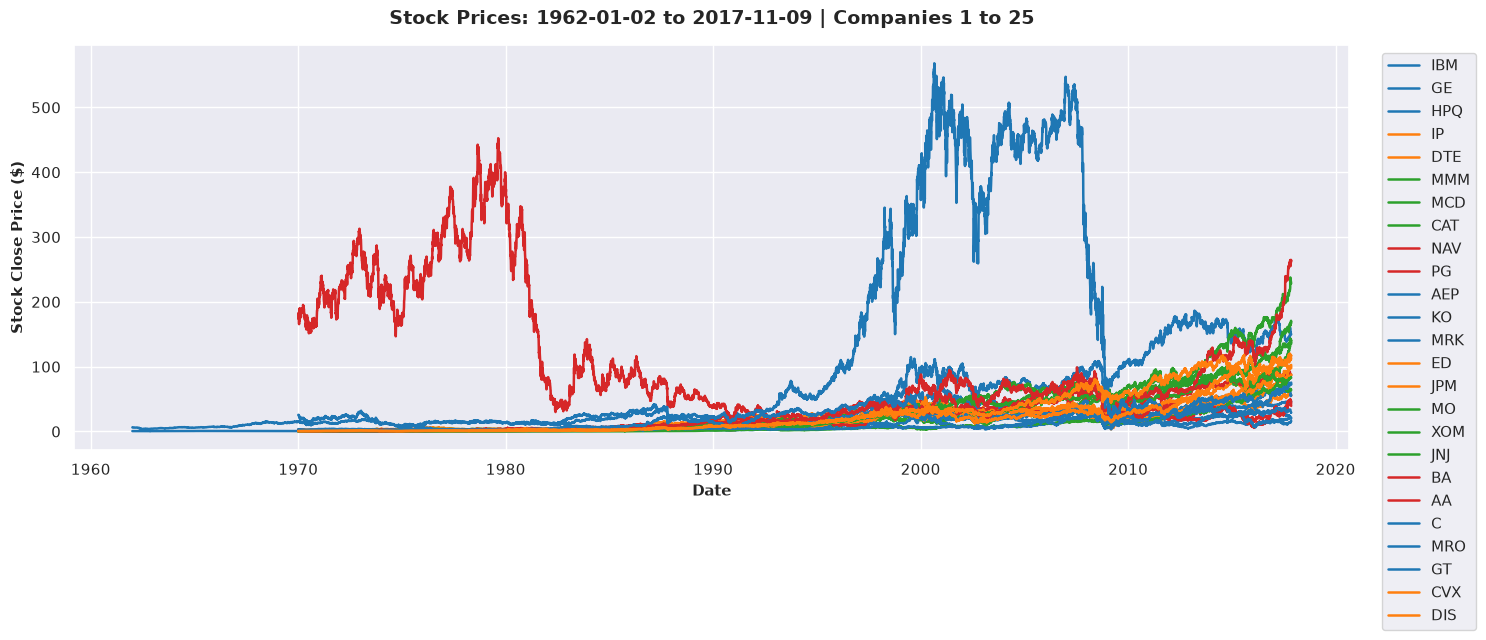

In [38]:
# ==========================================
# STEP 8: VARIABLE-BASED COMPANY RANGE & TIMELINE NAVIGATOR
# Uses pre-computed 'pivoted_stocks' & 'top_companies' from memory
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ---------------------------------------------------------
# 1. SET YOUR TIMELINE RANGE VARIABLES
# ---------------------------------------------------------
start_day = 0  # Offset from timeline start in trading days (e.g. 0, 500, 2000...)
window_size = 20000  # Number of trading days to display in window (e.g. 200, 500, 1000)

# ---------------------------------------------------------
# 2. SET YOUR COMPANY RANGE / SELECTION VARIABLES
# ---------------------------------------------------------
# Set USE_CUSTOM_TICKERS = False to select a range of companies by rank/index
# Set USE_CUSTOM_TICKERS = True to specify exact ticker names
USE_CUSTOM_TICKERS = False

# Option A: Company Range Settings (when USE_CUSTOM_TICKERS = False)
company_start_idx = 0  # Starting rank of company (0 = 1st company, 10 = 11th company...)
num_companies = 50  # How many companies to display from company_start_idx

# Option B: Specific Ticker Names (when USE_CUSTOM_TICKERS = True)
custom_tickers = ["aapl", "msft", "ibm", "ge", "xom", "jnj", "wmt", "cvx"]

# ---------------------------------------------------------
# 3. FAST DATA SLICING (IN MEMORY)
# ---------------------------------------------------------
# Filter Companies
if USE_CUSTOM_TICKERS:
  available_cols = pivoted_stocks.columns
  selected_cols = []
  for ticker in custom_tickers:
    matches = [
        c
        for c in available_cols
        if ticker.lower() in c.lower().replace(".us.txt", "")
    ]
    if matches:
      selected_cols.extend(matches)
  selected_cols = list(dict.fromkeys(selected_cols))  # Remove duplicates
else:
  # Slice company columns by range from ranked completeness
  selected_cols = top_companies[
      company_start_idx : company_start_idx + num_companies
  ]

# Filter Timeline Dates
dates_array = pivoted_stocks.index
total_days = len(dates_array)
start_idx = min(max(0, start_day), total_days - 50)
end_idx = min(start_idx + window_size, total_days - 1)

# Slice DataFrame in memory (< 0.01 seconds)
visible_dates = dates_array[start_idx:end_idx]
window_data = pivoted_stocks[selected_cols].iloc[start_idx:end_idx]

# ---------------------------------------------------------
# 4. PLOT RENDERING
# ---------------------------------------------------------
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(15, 6))

# Generate distinct colors for selected companies
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(selected_cols))))
for idx, comp in enumerate(selected_cols):
  ax.plot(
      visible_dates,
      window_data[comp],
      label=comp.replace(".us.txt", "").upper(),
      lw=1.8,
      color=colors[idx % 10],
  )

start_date_str = visible_dates[0].strftime("%Y-%m-%d")
end_date_str = visible_dates[-1].strftime("%Y-%m-%d")

# Add title and labels
ax.set_title(
    f"Stock Prices: {start_date_str} to {end_date_str} | Companies"
    f" {company_start_idx + 1} to {company_start_idx + len(selected_cols)}",
    fontsize=14,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Date", fontsize=11, weight="bold")
ax.set_ylabel("Stock Close Price ($)", fontsize=11, weight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.show()
